In [ ]:
pip install pandas scikit-learn xgboost


In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from scipy import interp
from itertools import cycle


# Configurar estilo de seaborn
sns.set(style="whitegrid")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Trabajo  Final de inteligencia de negocios/Data de panel/datos_abiertos_vigilancia_malaria.csv',
                         encoding="latin-1")

<ipython-input-4-1883f499f501>:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Trabajo  Final de inteligencia de negocios/Data de panel/datos_abiertos_vigilancia_malaria.csv',


In [ ]:
df.head()

,departamento,provincia,distrito,localidad,enfermedad,ano,semana,diagnostic,diresa,ubigeo,localcod,edad,tipo_edad,sexo
0,ANCASH,HUARMEY,HUARMEY,NaN,MALARIA P. FALCIPARUM,2000,6,B50,2,21101,NaN,2,A,M
1,ANCASH,HUARMEY,HUARMEY,NaN,MALARIA P. FALCIPARUM,2000,7,B50,2,21101,NaN,36,A,M
2,ANCASH,HUARMEY,HUARMEY,NaN,MALARIA P. FALCIPARUM,2000,15,B50,2,21101,NaN,7,M,F
3,ANCASH,RECUAY,PARARIN,NaN,MALARIA P. FALCIPARUM,2000,12,B50,2,21708,NaN,23,A,M
4,AYACUCHO,LA MAR,SAN MIGUEL,NaN,MALARIA P. FALCIPARUM,2000,16,B50,5,50501,NaN,17,A,M


In [ ]:
# Eliminar la columna 'localcod'
data = df.drop(columns=['localcod'])

In [ ]:
data.head()

,departamento,provincia,distrito,localidad,enfermedad,ano,semana,diagnostic,diresa,ubigeo,edad,tipo_edad,sexo
0,ANCASH,HUARMEY,HUARMEY,NaN,MALARIA P. FALCIPARUM,2000,6,B50,2,21101,2,A,M
1,ANCASH,HUARMEY,HUARMEY,NaN,MALARIA P. FALCIPARUM,2000,7,B50,2,21101,36,A,M
2,ANCASH,HUARMEY,HUARMEY,NaN,MALARIA P. FALCIPARUM,2000,15,B50,2,21101,7,M,F
3,ANCASH,RECUAY,PARARIN,NaN,MALARIA P. FALCIPARUM,2000,12,B50,2,21708,23,A,M
4,AYACUCHO,LA MAR,SAN MIGUEL,NaN,MALARIA P. FALCIPARUM,2000,16,B50,5,50501,17,A,M


In [ ]:
# Codificar variables categóricas
label_encoder = LabelEncoder()
categorical_columns = ['departamento', 'provincia', 'distrito', 'localidad', 'enfermedad', 'diagnostic', 'diresa', 'tipo_edad', 'sexo', 'edad', 'ubigeo']
for column in categorical_columns:
    data[column] = label_encoder.fit_transform(data[column])


In [ ]:
# Seleccionar características y etiquetas
X = data.drop(columns=['ano'])
y = data['ano']


In [ ]:

# Verificar la forma de y
print(f"Shape of y before reshape: {y.shape}")

Shape of y before reshape: (604968,)


In [ ]:
# Asegurarnos de que y sea un vector unidimensional
if y.ndim > 1:
    y = y.values.argmax(axis=1)

In [ ]:

# Verificar la forma de y después de reshape
print(f"Shape of y after reshape: {y.shape}")

Shape of y after reshape: (604968,)


In [ ]:
# Binarizar las etiquetas para ROC-AUC multiclase
y_bin = label_binarize(y, classes=np.unique(y))
n_classes = y_bin.shape[1]

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Escalar las características
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Función para entrenar y evaluar modelos
def train_and_evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Evaluación del modelo {model.__class__.__name__}")
    print(classification_report(y_test, y_pred))


## RANDOM FOREST

In [ ]:
# Entrenar el modelo de Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
# Reporte de clasificación y matriz de confusión
print("Random Forest Report")
print(classification_report(y_test, y_pred_rf))

Random Forest Report
              precision    recall  f1-score   support

        2000       0.62      0.59      0.61        17
        2001       0.25      0.09      0.13        11
        2002       0.00      0.00      0.00         2
        2003       0.48      0.49      0.49      2734
        2004       0.42      0.44      0.43      2714
        2005       0.47      0.48      0.48      3092
        2006       0.36      0.34      0.35      1720
        2007       0.47      0.49      0.48      1534
        2008       0.39      0.36      0.38       885
        2009       0.42      0.41      0.42      7364
        2010       0.46      0.48      0.47      5762
        2011       0.33      0.30      0.31      4583
        2012       0.31      0.31      0.31      6347
        2013       0.30      0.30      0.30      9720
        2014       0.32      0.35      0.34     13022
        2015       0.33      0.35      0.34     12729
        2016       0.33      0.34      0.34     11359
      

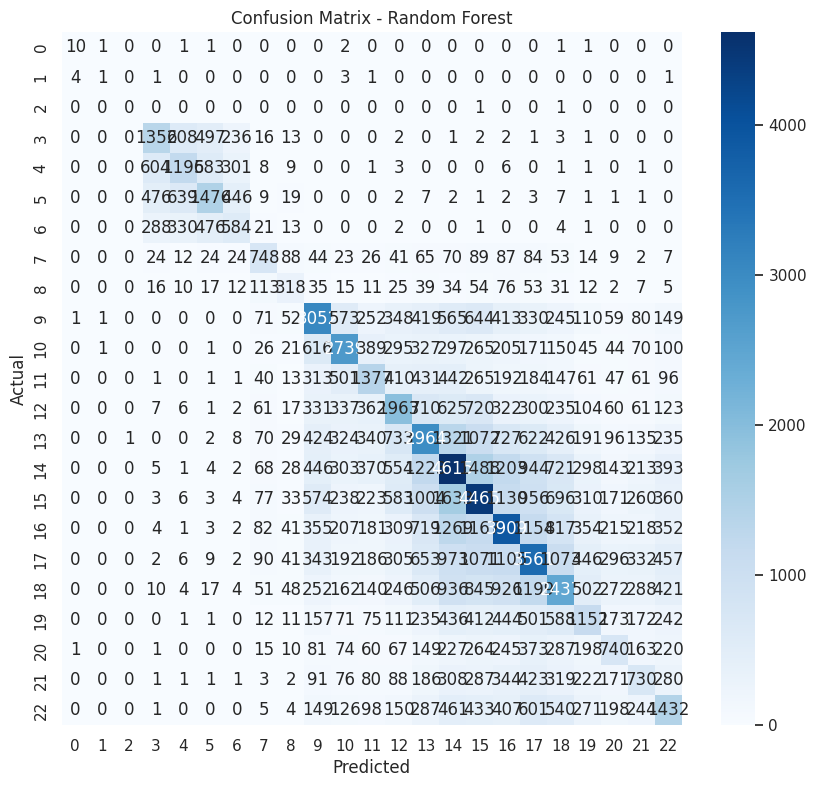

In [ ]:
# Matriz de confusión
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10, 9))
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Importancia de características
feature_importances = pd.DataFrame(rf.feature_importances_,
                                   index=X.columns,
                                   columns=['importance']).sort_values('importance', ascending=False)

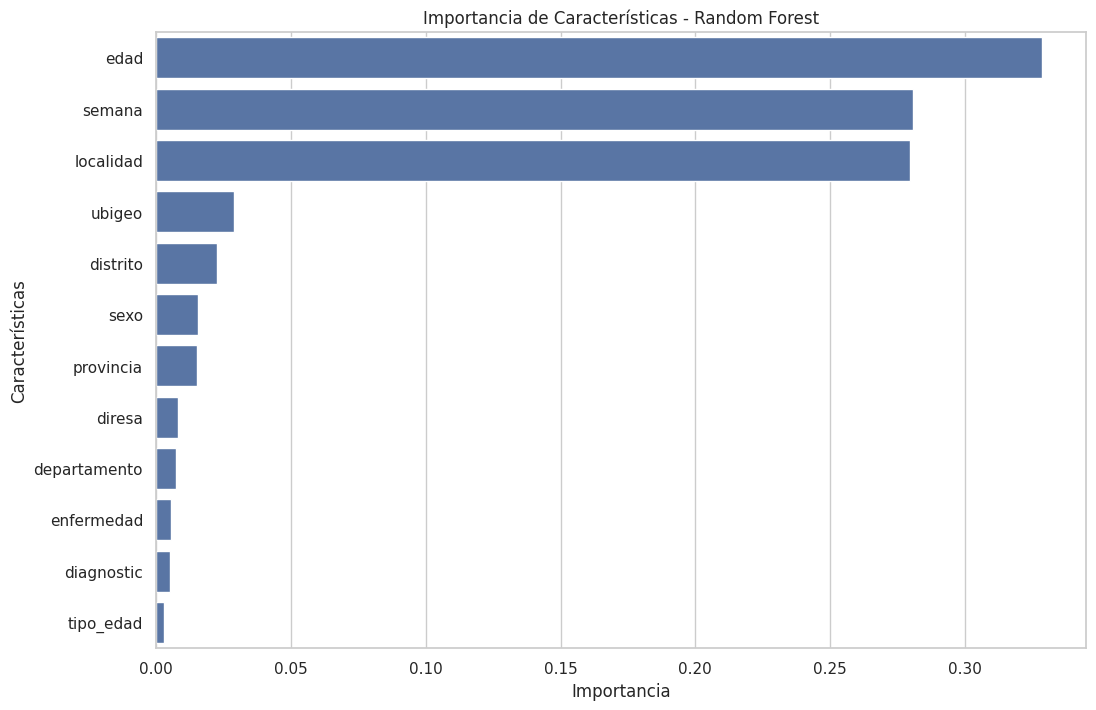

In [ ]:
# Gráfico de barras de importancia de características
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances['importance'], y=feature_importances.index)
plt.title('Importancia de Características - Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.show()

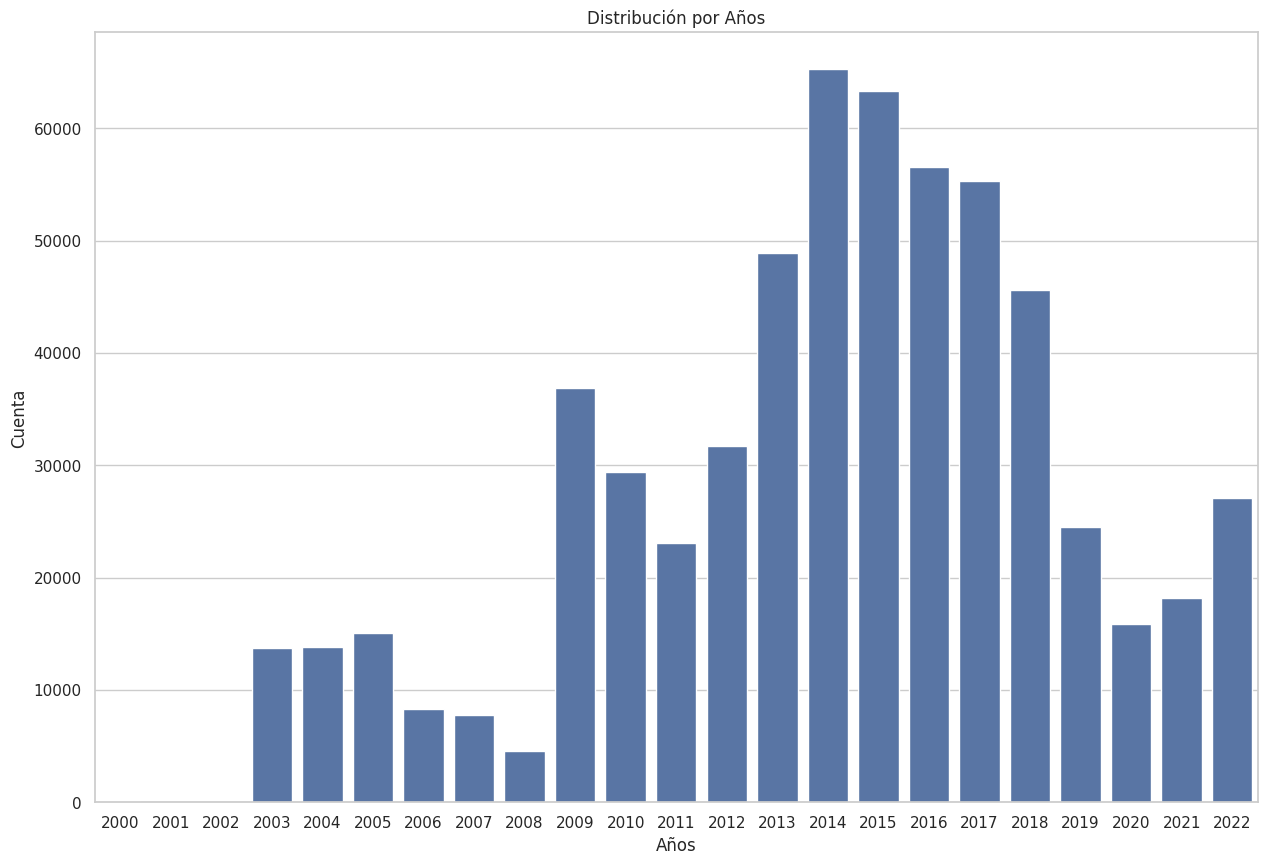

In [ ]:
# Visualización de la distribución de la variable objetivo
plt.figure(figsize=(15,10))
sns.countplot(x='ano', data=data)
plt.title('Distribución por Años')
plt.xlabel('Años')
plt.ylabel('Cuenta')
plt.show()

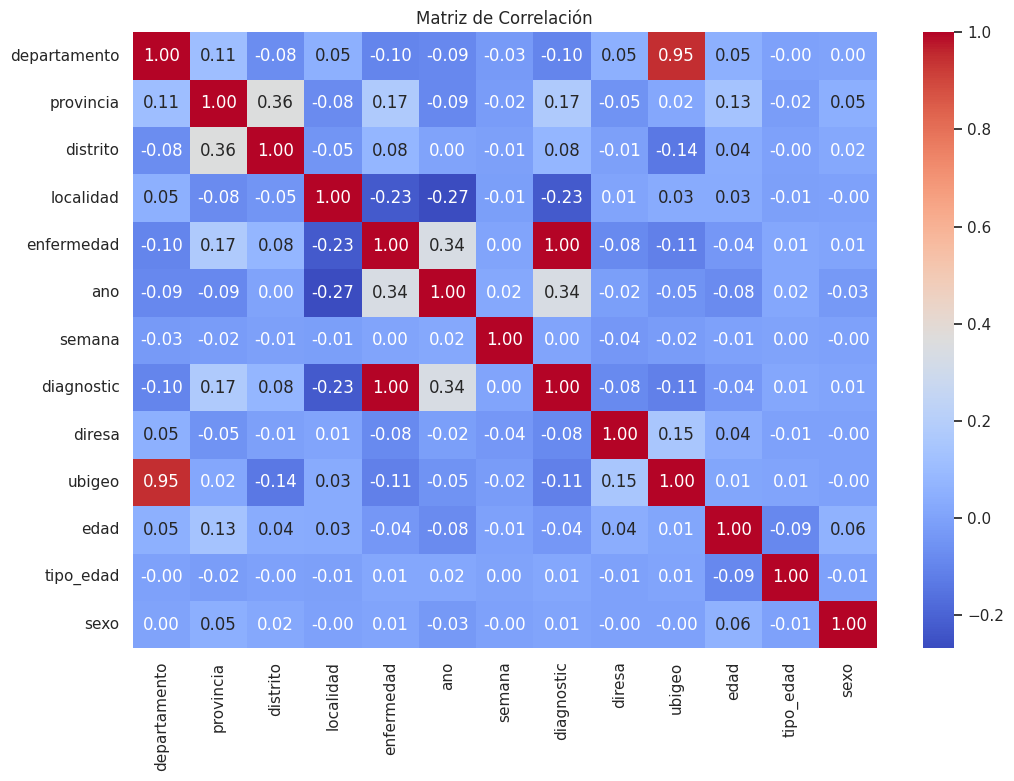

In [ ]:
# Matriz de Correlación
plt.figure(figsize=(12, 8))
corr_matrix = data.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

## ARBOL DE DECISIÓN

In [ ]:
# Entrenar el modelo de Árbol de Decisión
dtree = DecisionTreeClassifier(max_depth=3, random_state=42)
dtree.fit(X_train, y_train)
y_pred_dtree = dtree.predict(X_test)

In [ ]:
# Reporte de clasificación y matriz de confusión
print("Decision Tree Report")
print(classification_report(y_test, y_pred_dtree))

Decision Tree Report


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

        2000       0.00      0.00      0.00        17
        2001       0.00      0.00      0.00        11
        2002       0.00      0.00      0.00         2
        2003       0.45      0.27      0.34      2734
        2004       0.00      0.00      0.00      2714
        2005       0.32      0.94      0.48      3092
        2006       0.00      0.00      0.00      1720
        2007       0.00      0.00      0.00      1534
        2008       0.00      0.00      0.00       885
        2009       0.00      0.00      0.00      7364
        2010       0.26      0.60      0.36      5762
        2011       0.00      0.00      0.00      4583
        2012       0.00      0.00      0.00      6347
        2013       0.00      0.00      0.00      9720
        2014       0.13      0.93      0.22     13022
        2015       0.00      0.00      0.00     12729
        2016       0.00      0.00      0.00     11359
        2017       0.00    

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


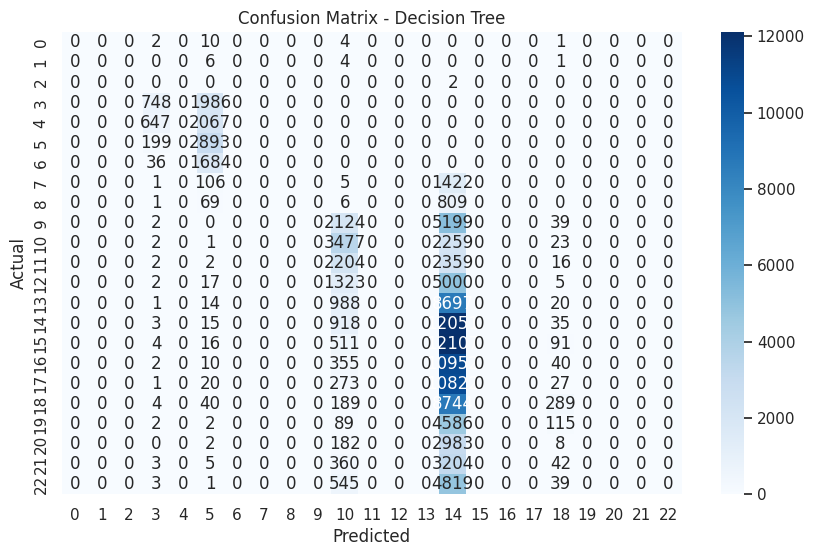

In [ ]:
# Matriz de confusión
conf_matrix_dtree = confusion_matrix(y_test, y_pred_dtree)
plt.figure(figsize=(10, 6))
sns.heatmap(conf_matrix_dtree, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# Importancia de características
feature_importances = pd.DataFrame(dtree.feature_importances_,
                                   index=X.columns,
                                   columns=['importance']).sort_values('importance', ascending=False)

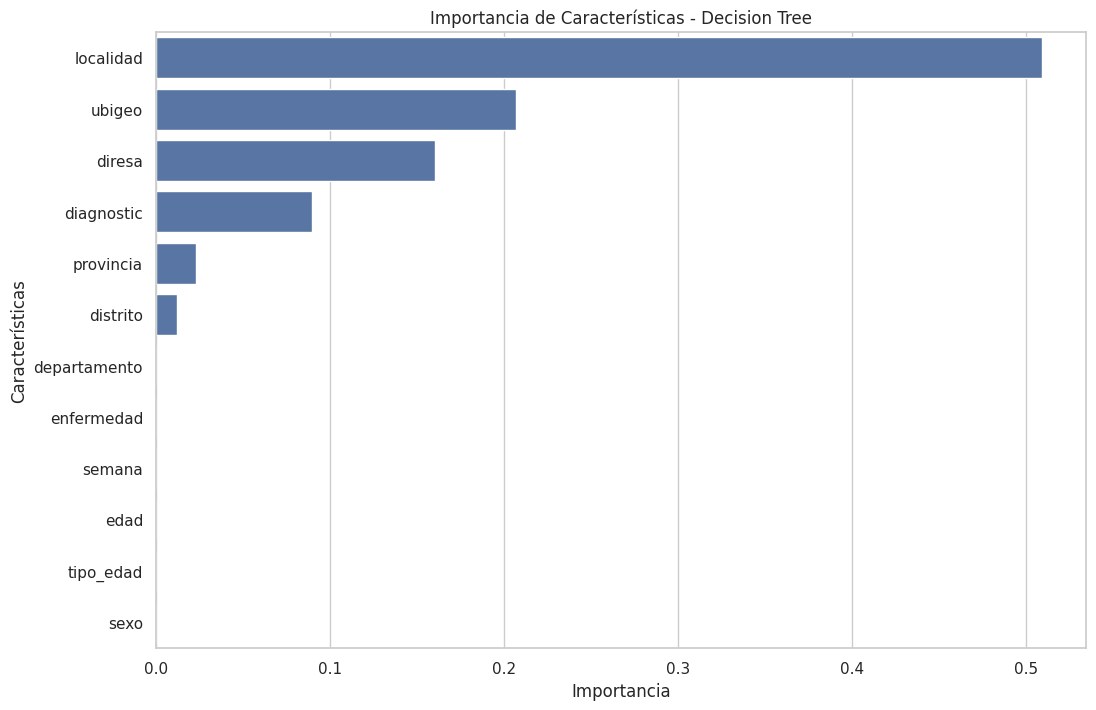

In [ ]:
# Gráfico de barras de importancia de características
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances['importance'], y=feature_importances.index)
plt.title('Importancia de Características - Decision Tree')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.show()

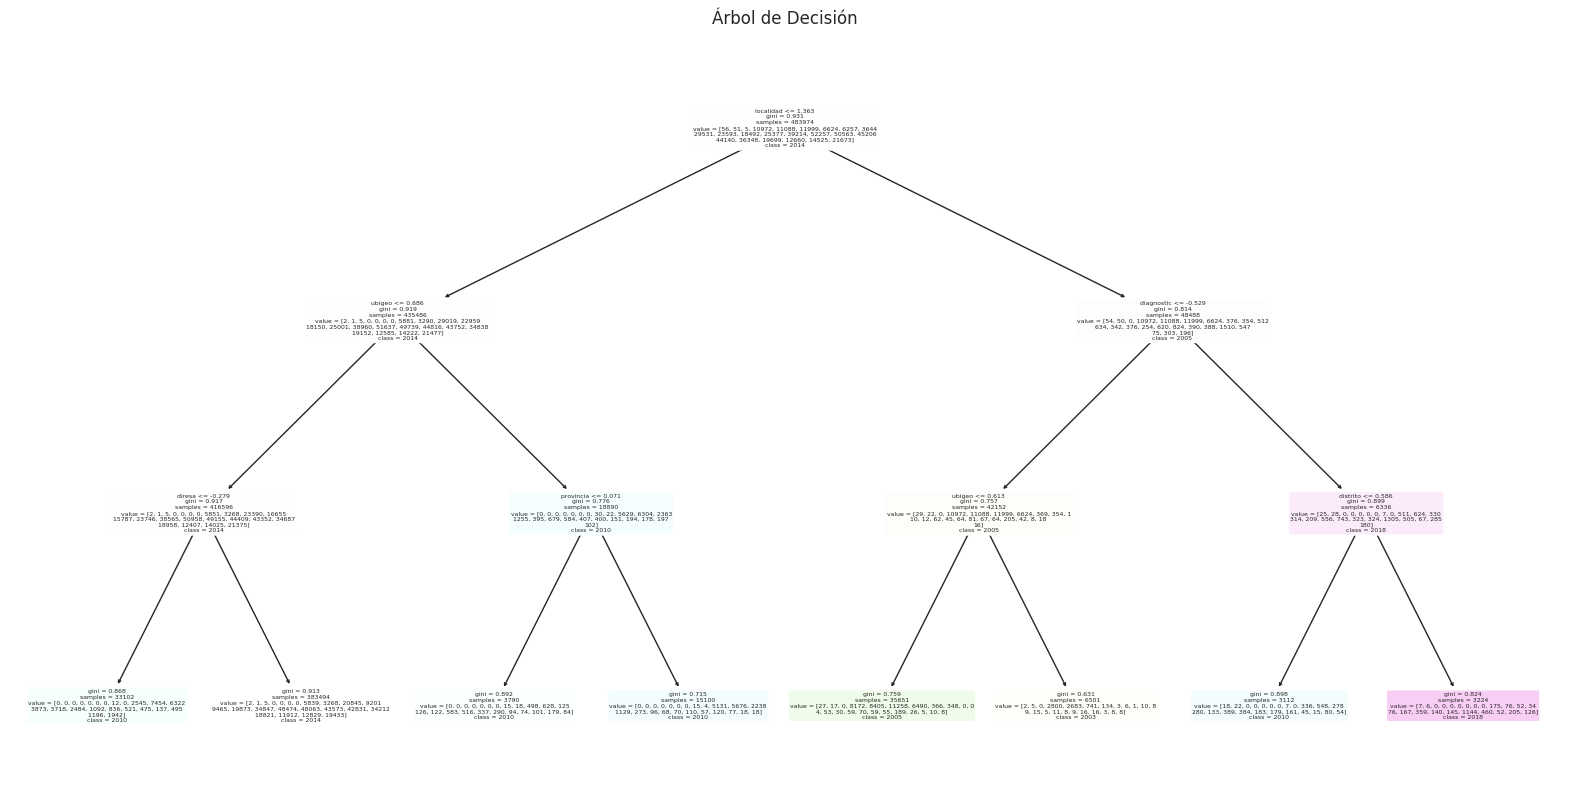

In [ ]:
# Visualización del árbol de decisión

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix

plt.figure(figsize=(20,10))
plot_tree(dtree, feature_names=X.columns, class_names=np.unique(y).astype(str), filled=True, rounded=True)
plt.title('Árbol de Decisión')
plt.show()

## GRADIENT BOOSTING CLASSIFIER

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Entrenar el modelo de Gradient Boosting Machines
gbm = GradientBoostingClassifier(random_state=42)
gbm.fit(X_train, y_train)
y_pred_gbm = gbm.predict(X_test)


In [ ]:
# Reporte de clasificación y matriz de confusión
print("Gradient Boosting Machines Report")
print(classification_report(y_test, y_pred_gbm))

Gradient Boosting Machines Report


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

        2000       0.00      0.00      0.00        17
        2001       0.00      0.27      0.00        11
        2002       0.00      0.00      0.00         2
        2003       0.43      0.50      0.46      2734
        2004       0.40      0.24      0.30      2714
        2005       0.39      0.65      0.49      3092
        2006       0.49      0.08      0.14      1720
        2007       0.31      0.37      0.34      1534
        2008       0.35      0.27      0.31       885
        2009       0.36      0.29      0.32      7364
        2010       0.41      0.47      0.44      5762
        2011       0.31      0.23      0.26      4583
        2012       0.38      0.14      0.20      6347
        2013       0.22      0.24      0.23      9720
        2014       0.23      0.39      0.29     13022
        2015       0.23      0.33      0.27     12729
        2016       0.24      0.30      0.27     11359
        2017       0.22    

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


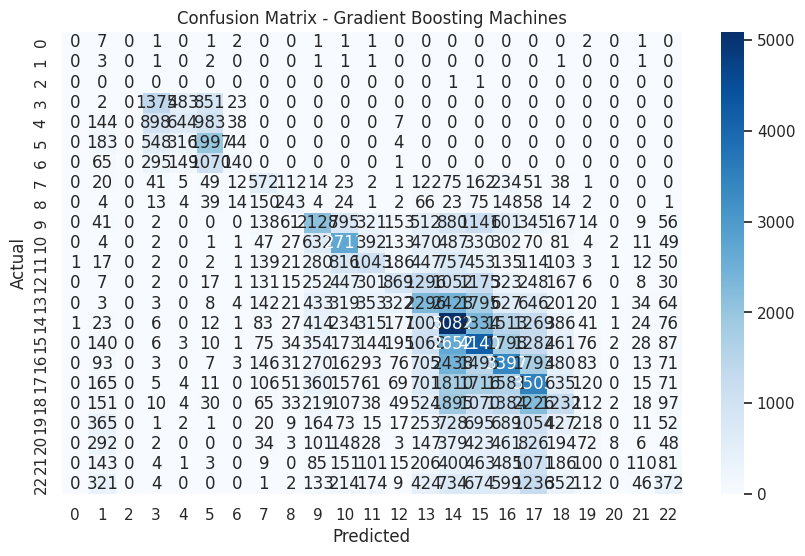

In [ ]:
# Matriz de confusión
conf_matrix_gbm = confusion_matrix(y_test, y_pred_gbm)
plt.figure(figsize=(10, 6))
sns.heatmap(conf_matrix_gbm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Gradient Boosting Machines")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Importancia de características
feature_importances = pd.DataFrame(gbm.feature_importances_,
                                   index=X.columns,
                                   columns=['importance']).sort_values('importance', ascending=False)

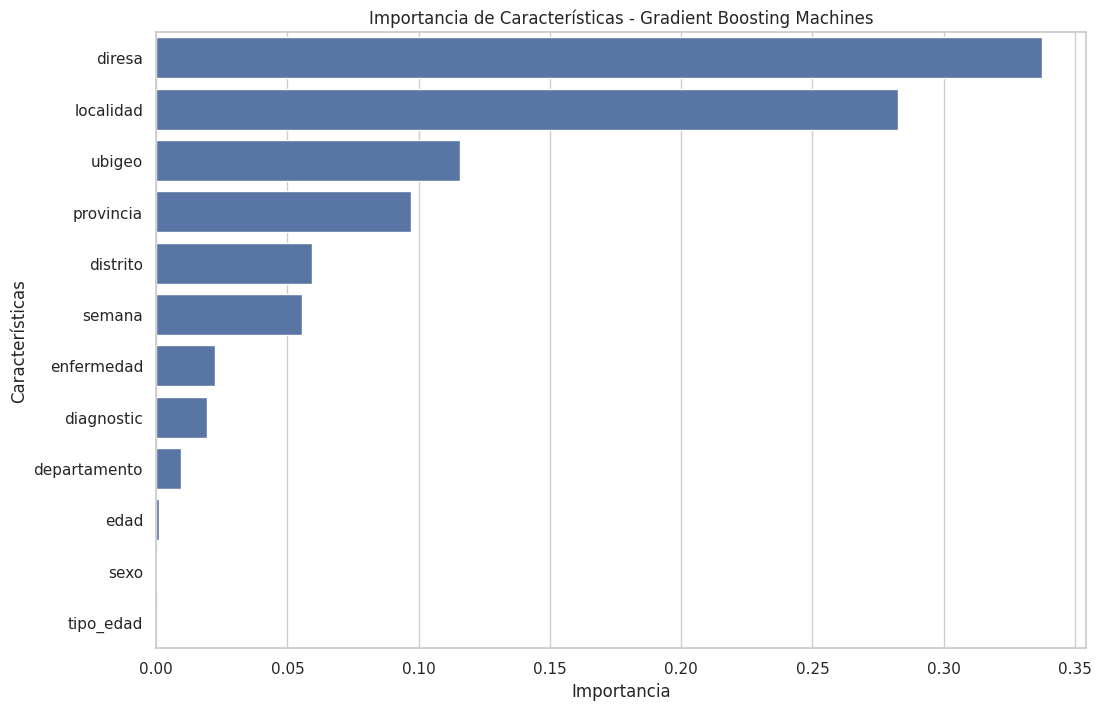

In [ ]:
# Gráfico de barras de importancia de características
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances['importance'], y=feature_importances.index)
plt.title('Importancia de Características - Gradient Boosting Machines')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.show()

## REDES NEURONALES

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [ ]:
# Codificar las etiquetas a formato categórico (one-hot encoding)
y = label_encoder.fit_transform(y)
y = to_categorical(y)

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Escalar las características
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Definir el modelo de red neuronal
model = Sequential()
model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(y.shape[1], activation='softmax'))

In [ ]:
from tensorflow.keras.optimizers import Adam

In [ ]:
# Compilar el modelo
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

In [ ]:
# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=2)

Epoch 1/50
15125/15125 - 78s - loss: 2.3573 - accuracy: 0.1844 - val_loss: 2.2491 - val_accuracy: 0.2079 - 78s/epoch - 5ms/step
Epoch 2/50
15125/15125 - 83s - loss: 2.2836 - accuracy: 0.2021 - val_loss: 2.2270 - val_accuracy: 0.2168 - 83s/epoch - 5ms/step
Epoch 3/50
15125/15125 - 41s - loss: 2.2692 - accuracy: 0.2064 - val_loss: 2.2170 - val_accuracy: 0.2200 - 41s/epoch - 3ms/step
Epoch 4/50
15125/15125 - 42s - loss: 2.2611 - accuracy: 0.2097 - val_loss: 2.2099 - val_accuracy: 0.2229 - 42s/epoch - 3ms/step
Epoch 5/50
15125/15125 - 43s - loss: 2.2559 - accuracy: 0.2123 - val_loss: 2.2045 - val_accuracy: 0.2246 - 43s/epoch - 3ms/step
Epoch 6/50
15125/15125 - 46s - loss: 2.2513 - accuracy: 0.2132 - val_loss: 2.2011 - val_accuracy: 0.2260 - 46s/epoch - 3ms/step
Epoch 7/50
15125/15125 - 43s - loss: 2.2496 - accuracy: 0.2138 - val_loss: 2.1982 - val_accuracy: 0.2298 - 43s/epoch - 3ms/step
Epoch 8/50
15125/15125 - 38s - loss: 2.2458 - accuracy: 0.2147 - val_loss: 2.1900 - val_accuracy: 0.2285

In [ ]:
# Evaluar el modelo en el conjunto de prueba
loss, accuracy = model.evaluate(X_test, y_test, verbose=2)
print(f'Precisión del modelo en el conjunto de prueba: {accuracy:.2f}')

3782/3782 - 9s - loss: 2.1666 - accuracy: 0.2433 - 9s/epoch - 2ms/step
Precisión del modelo en el conjunto de prueba: 0.24


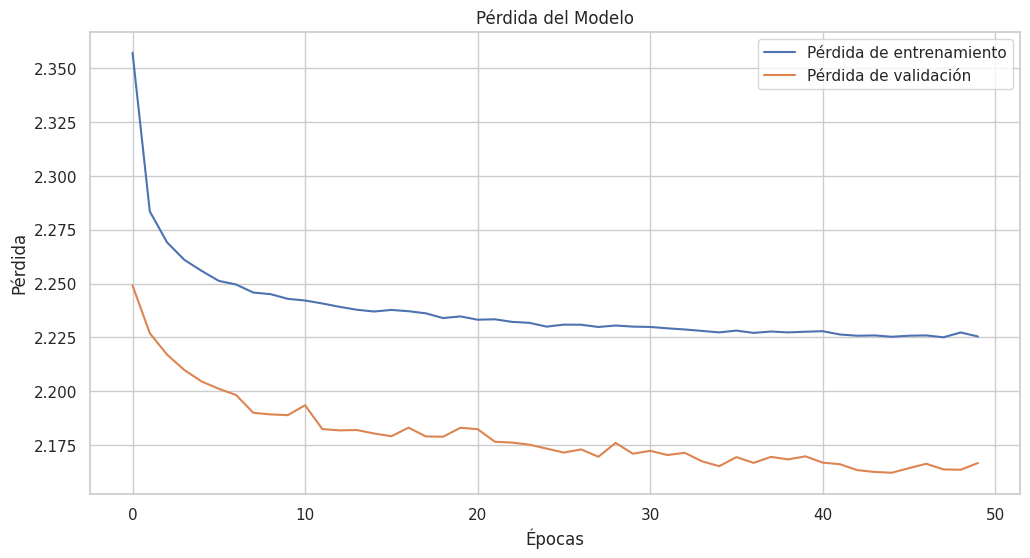

In [ ]:
# Graficar la pérdida del modelo a través de las épocas
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Pérdida del Modelo')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

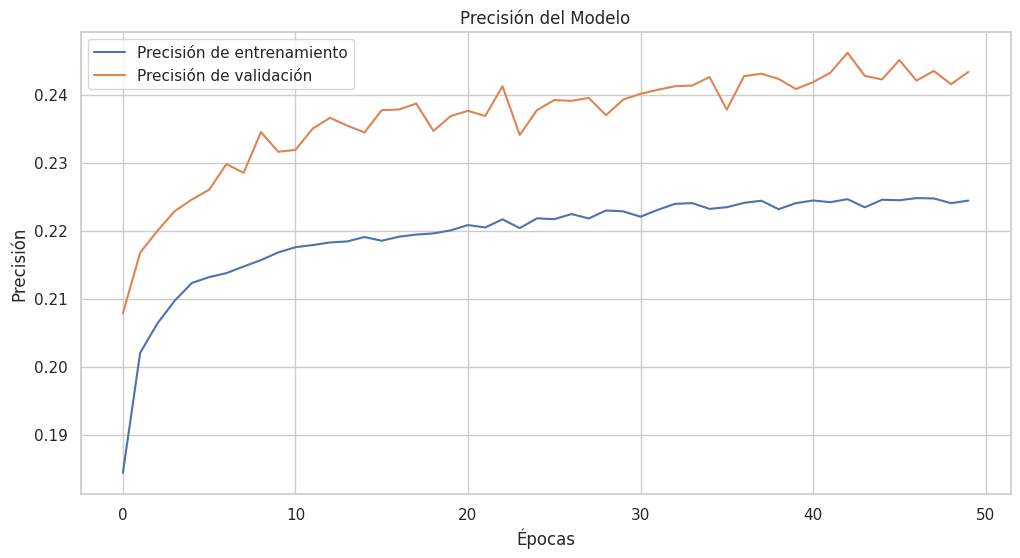

In [ ]:
# Graficar la precisión del modelo a través de las épocas
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Precisión de entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión de validación')
plt.title('Precisión del Modelo')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()

# K-Nearest Neighbors (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.67      0.47      0.55        17
           1       0.50      0.09      0.15        11
           2       0.00      0.00      0.00         2
           3       0.50      0.34      0.40      2734
           4       0.45      0.30      0.36      2714
           5       0.46      0.31      0.37      3092
           6       0.41      0.18      0.25      1720
           7       0.44      0.14      0.21      1534
           8       0.50      0.15      0.23       885
           9       0.53      0.22      0.31      7364
          10       0.56      0.31      0.40      5762
          11       0.42      0.14      0.21      4583
          12       0.40      0.11      0.17      6347
          13       0.32      0.09      0.14      9720
          14       0.34      0.12      0.18     13022
          15       0.35      0.12      0.17     12729
          16       0.35      0.11      0.17     11359
          17       0.34    

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix



In [ ]:


# Imprimir el informe de clasificación
print(classification_report(y_test, y_pred))



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       0.67      0.47      0.55        17
           1       0.50      0.09      0.15        11
           2       0.00      0.00      0.00         2
           3       0.50      0.34      0.40      2734
           4       0.45      0.30      0.36      2714
           5       0.46      0.31      0.37      3092
           6       0.41      0.18      0.25      1720
           7       0.44      0.14      0.21      1534
           8       0.50      0.15      0.23       885
           9       0.53      0.22      0.31      7364
          10       0.56      0.31      0.40      5762
          11       0.42      0.14      0.21      4583
          12       0.40      0.11      0.17      6347
          13       0.32      0.09      0.14      9720
          14       0.34      0.12      0.18     13022
          15       0.35      0.12      0.17     12729
          16       0.35      0.11      0.17     11359
          17       0.34    

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Regresión Logística

In [ ]:
from sklearn.linear_model import LogisticRegression

# Entrenar el modelo de Regresión Logística
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Imprimir el informe de clasificación
print(classification_report(y_test, y_pred))



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

        2000       0.00      0.00      0.00        17
        2001       0.00      0.00      0.00        11
        2002       0.00      0.00      0.00         2
        2003       0.33      0.59      0.42      2734
        2004       0.27      0.07      0.11      2714
        2005       0.34      0.66      0.45      3092
        2006       0.50      0.02      0.04      1720
        2007       0.16      0.11      0.13      1534
        2008       0.46      0.12      0.19       885
        2009       0.26      0.11      0.16      7364
        2010       0.21      0.32      0.25      5762
        2011       0.27      0.14      0.19      4583
        2012       0.24      0.05      0.08      6347
        2013       0.14      0.06      0.08      9720
        2014       0.15      0.44      0.22     13022
        2015       0.17      0.21      0.19     12729
        2016       0.15      0.14      0.15     11359
        2017       0.15    

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
# Crear una matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)



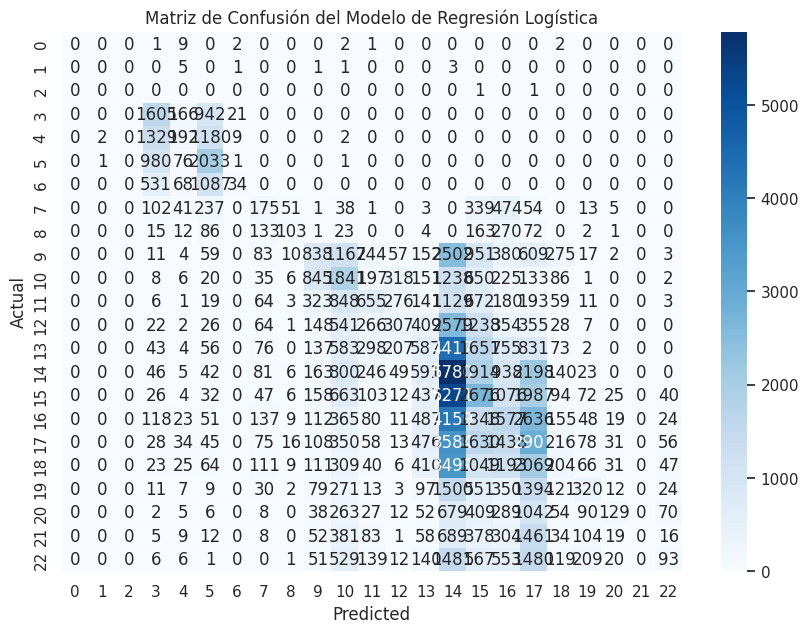

In [ ]:
# Visualizar la matriz de confusión
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Matriz de Confusión del Modelo de Regresión Logística")
plt.show()

# Modelo SVM


In [ ]:
from sklearn.svm import SVC

# Entrenar el modelo SVM
model = SVC(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)




In [ ]:
# Imprimir el informe de clasificación
print(classification_report(y_test, y_pred))



In [ ]:
# Crear una matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)



In [ ]:
# Visualizar la matriz de confusión
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Matriz de Confusión del Modelo SVM")
plt.show()

# Modelo Gradient Boosting



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Entrenar el modelo Gradient Boosting
model = GradientBoostingClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)



In [ ]:
# Imprimir el informe de clasificación
print(classification_report(y_test, y_pred))



In [ ]:
# Crear una matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)



In [ ]:
# Visualizar la matriz de confusión
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Matriz de Confusión del Modelo Gradient Boosting")
plt.show()


# Modelo XGBoost


In [ ]:
import xgboost as xgb

# Entrenar el modelo XGBoost
model = xgb.XGBClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)




In [ ]:
# Imprimir el informe de clasificación
print(classification_report(y_test, y_pred))



In [ ]:
# Crear una matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)



In [ ]:
# Visualizar la matriz de confusión
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Matriz de Confusión del Modelo XGBoost")
plt.show()

# Modelo MLP (Perceptrón Multicapa)


In [ ]:
from sklearn.neural_network import MLPClassifier

# Entrenar el modelo MLP
model = MLPClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)



In [ ]:
# Imprimir el informe de clasificación
print(classification_report(y_test, y_pred))




In [ ]:
# Crear una matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)



In [ ]:
# Visualizar la matriz de confusión
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Matriz de Confusión del Modelo MLP")
plt.show()